In [1]:
pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 74.8 MB/s eta 0:00:00


Depth profile ZOTUs:   6014
Depth profile samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Depth samples found: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Richness at depth:
   Sample  Depth_cm  Richness
IX.10CM.A        10      2027
IX.20CM.B        20      1952
IX.30CM.A        30      1719
IX.40CM.A        40      1484
IX.50CM.A        50      1737
IX.60CM.A        60      1888
IX.70CM.A        70      1972
IX.80CM.A        80      2031

Spearman rho = 0.238  p = 0.5702  ns


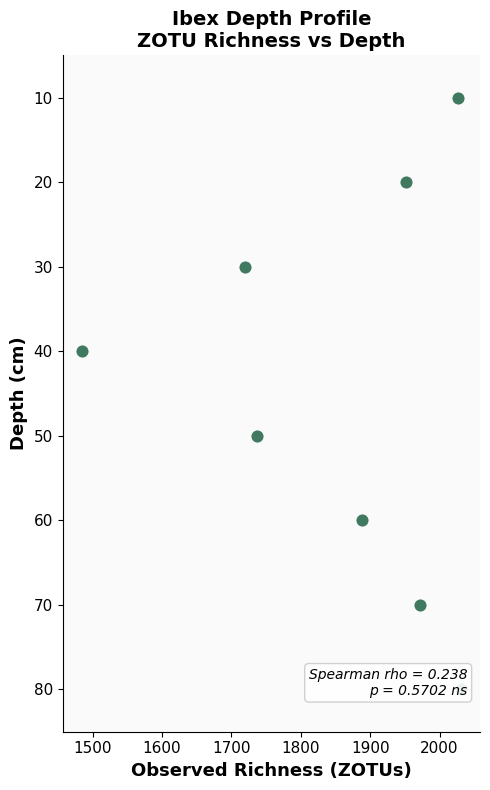

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================
# LOAD DEPTH PROFILE FILE
# ============================
depth_count_path = "/content/zotutab_decontam_Final_Depth_Only.csv"

raw_d = pd.read_csv(depth_count_path, header=None)

first_val = str(raw_d.iloc[0, 0]).strip().upper()
if first_val == "ANATOMY":
    header_row_d = 1
    data_start_d = 2
else:
    header_row_d = 0
    data_start_d = 1

df_d = raw_d.iloc[data_start_d:].copy()
df_d.columns = raw_d.iloc[header_row_d].values
df_d.reset_index(drop=True, inplace=True)

tax_cols  = ["Domain", "Phylum", "Class", "Order",
             "Family", "Genus", "Species"]
zotu_col_d = df_d.columns[0]

sample_cols_d = [c for c in df_d.columns
                 if c not in tax_cols
                 and c != zotu_col_d
                 and "Blank" not in str(c)]

df_d[sample_cols_d] = df_d[sample_cols_d].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_d["Domain"] = df_d["Domain"].str.lower().str.strip()
df_d["Phylum"] = df_d["Phylum"].str.lower().str.strip()

micro_d = df_d[
    df_d["Domain"].isin(["bacteria", "archaea"]) &
    (df_d["Phylum"] != "bacteria") &
    df_d["Phylum"].notna()
].copy()

print(f"Depth profile ZOTUs:   {len(micro_d)}")
print(f"Depth profile samples: {sample_cols_d}")

# ============================
# DEPTH MAP
# ============================
depth_map = {
    "IX.10CM.A":  10,
    "IX.20CM.B":  20,
    "IX.30CM.A":  30,
    "IX.40CM.A":  40,
    "IX.50CM.A":  50,
    "IX.60CM.A":  60,
    "IX.70CM.A":  70,
    "IX.80CM.A":  80,
}

depth_samples = [s for s in sample_cols_d if s in depth_map]
depth_samples.sort(key=lambda s: depth_map[s])
print(f"\nDepth samples found: {depth_samples}")

# ============================
# RICHNESS PER DEPTH SAMPLE
# ============================
def compute_richness(counts):
    counts = counts[counts > 0]
    return len(counts)

records = []
for s in depth_samples:
    counts = micro_d[s].values.astype(float)
    rich   = compute_richness(counts)
    records.append({
        "Sample":   s,
        "Depth_cm": depth_map[s],
        "Richness": rich,
    })

alpha_depth = pd.DataFrame(records)
print(f"\nRichness at depth:")
print(alpha_depth[["Sample", "Depth_cm",
                    "Richness"]].to_string(index=False))

# ============================
# SPEARMAN CORRELATION
# ============================
r, p = spearmanr(alpha_depth["Depth_cm"],
                 alpha_depth["Richness"])
sig  = ("***" if p < 0.001 else "**" if p < 0.01
        else "*" if p < 0.05 else "ns")

print(f"\nSpearman rho = {r:.3f}  p = {p:.4f}  {sig}")

# ============================
# FIGURE
# x = richness, y = depth
# y axis inverted so surface is at top
# no regression line, no depth labels
# ============================
fig, ax = plt.subplots(figsize=(5, 8))
fig.patch.set_facecolor("white")

color = "#2d6a4f"

ax.scatter(alpha_depth["Richness"],
           alpha_depth["Depth_cm"],
           color=color, s=90,
           edgecolors="white", linewidths=0.8,
           alpha=0.9, zorder=3)

# invert y axis so 0 cm is at top
ax.invert_yaxis()

# stats box
ax.text(0.97, 0.05,
        f"Spearman rho = {r:.3f}\n"
        f"p = {p:.4f} {sig}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

ax.set_xlabel("Observed Richness (ZOTUs)",
              fontsize=13, fontweight="bold")
ax.set_ylabel("Depth (cm)",
              fontsize=13, fontweight="bold")
ax.set_title(
    "Ibex Depth Profile\nZOTU Richness vs Depth",
    fontsize=14, fontweight="bold")

ax.set_ylim(85, 5)
ax.tick_params(labelsize=11)
ax.set_facecolor("#fafafa")
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

plt.tight_layout()

plt.show()


Depth profile ZOTUs: 6014
Surface ZOTUs: 6014
Depth samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Surface sample IX.1B richness: 1477

All data points:
   Sample  Depth_cm  Richness    Type
    IX.1B         0      1477 surface
IX.10CM.A        10      2027   depth
IX.20CM.B        20      1952   depth
IX.30CM.A        30      1719   depth
IX.40CM.A        40      1484   depth
IX.50CM.A        50      1737   depth
IX.60CM.A        60      1888   depth
IX.70CM.A        70      1972   depth
IX.80CM.A        80      2031   depth

Spearman rho = 0.238  p = 0.5702  ns
(depth samples only — surface point shown for context)


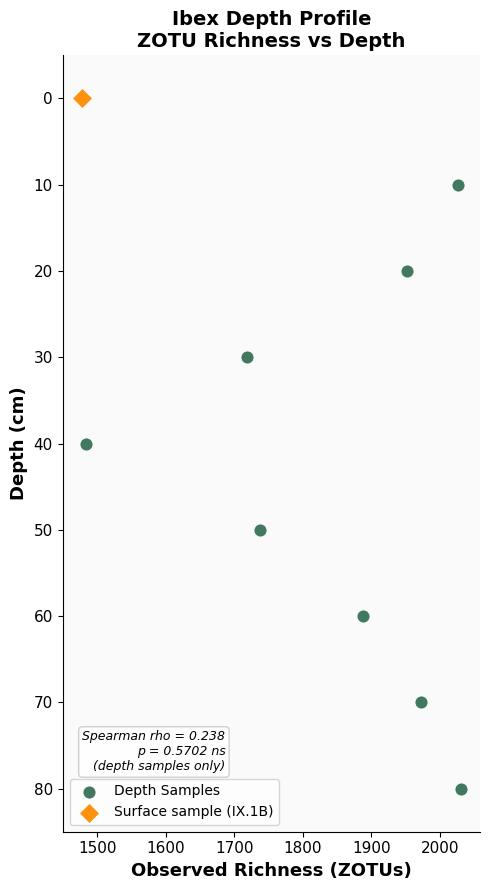

Saved: ibex_depth_richness.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================
# PATHS
# ============================
depth_count_path  = "/content/zotutab_decontam_Final_Depth_Only.csv"
surface_count_path = "/content/zotutab_decontam_Final.csv"

# ============================
# TAXONOMY COLUMNS
# ============================
tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]

# ============================
# LOAD DEPTH FILE
# ============================
raw_d     = pd.read_csv(depth_count_path, header=None)
first_val = str(raw_d.iloc[0, 0]).strip().upper()
if first_val == "ANATOMY":
    header_row_d = 1
    data_start_d = 2
else:
    header_row_d = 0
    data_start_d = 1

df_d = raw_d.iloc[data_start_d:].copy()
df_d.columns = raw_d.iloc[header_row_d].values
df_d.reset_index(drop=True, inplace=True)

zotu_col_d    = df_d.columns[0]
sample_cols_d = [c for c in df_d.columns
                 if c not in tax_cols
                 and c != zotu_col_d
                 and "Blank" not in str(c)]

df_d[sample_cols_d] = df_d[sample_cols_d].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_d["Domain"] = df_d["Domain"].str.lower().str.strip()
df_d["Phylum"] = df_d["Phylum"].str.lower().str.strip()

micro_d = df_d[
    df_d["Domain"].isin(["bacteria", "archaea"]) &
    (df_d["Phylum"] != "bacteria") &
    df_d["Phylum"].notna()
].copy()

print(f"Depth profile ZOTUs: {len(micro_d)}")

# ============================
# LOAD SURFACE FILE
# to get IX.1B richness
# ============================
raw_s     = pd.read_csv(surface_count_path, header=None)
first_val_s = str(raw_s.iloc[0, 0]).strip().upper()
if first_val_s == "ANATOMY":
    header_row_s = 1
    data_start_s = 2
else:
    header_row_s = 0
    data_start_s = 1

df_s = raw_s.iloc[data_start_s:].copy()
df_s.columns = raw_s.iloc[header_row_s].values
df_s.reset_index(drop=True, inplace=True)

zotu_col_s    = df_s.columns[0]
sample_cols_s = [c for c in df_s.columns
                 if c not in tax_cols
                 and c != zotu_col_s
                 and "Blank" not in str(c)]

df_s[sample_cols_s] = df_s[sample_cols_s].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_s["Domain"] = df_s["Domain"].str.lower().str.strip()
df_s["Phylum"] = df_s["Phylum"].str.lower().str.strip()

micro_s = df_s[
    df_s["Domain"].isin(["bacteria", "archaea"]) &
    (df_s["Phylum"] != "bacteria") &
    df_s["Phylum"].notna()
].copy()

print(f"Surface ZOTUs: {len(micro_s)}")

# ============================
# DEPTH MAP
# ============================
depth_map = {
    "IX.10CM.A":  10,
    "IX.20CM.B":  20,
    "IX.30CM.A":  30,
    "IX.40CM.A":  40,
    "IX.50CM.A":  50,
    "IX.60CM.A":  60,
    "IX.70CM.A":  70,
    "IX.80CM.A":  80,
}

depth_samples = [s for s in sample_cols_d if s in depth_map]
depth_samples.sort(key=lambda s: depth_map[s])
print(f"Depth samples: {depth_samples}")

# ============================
# RICHNESS FUNCTION
# ============================
def compute_richness(counts):
    return len(counts[counts > 0])

# ============================
# DEPTH SAMPLE RICHNESS
# ============================
records = []
for s in depth_samples:
    counts = micro_d[s].values.astype(float)
    rich   = compute_richness(counts)
    records.append({
        "Sample":   s,
        "Depth_cm": depth_map[s],
        "Richness": rich,
        "Type":     "depth"
    })

# ============================
# SURFACE SAMPLE — IX.1B at 0 cm
# ============================
surface_sample = "IX.1B"
if surface_sample in micro_s.columns:
    surf_counts = micro_s[surface_sample].values.astype(float)
    surf_rich   = compute_richness(surf_counts)
    records.insert(0, {
        "Sample":   surface_sample,
        "Depth_cm": 0,
        "Richness": surf_rich,
        "Type":     "surface"
    })
    print(f"\nSurface sample {surface_sample} richness: {surf_rich}")
else:
    print(f"\nWARNING: {surface_sample} not found in surface file")

alpha_depth = pd.DataFrame(records)
print(f"\nAll data points:")
print(alpha_depth[["Sample", "Depth_cm",
                    "Richness", "Type"]].to_string(index=False))

# ============================
# SPEARMAN — depth samples only
# surface point excluded from stats
# since it is from a different file
# ============================
depth_only = alpha_depth[alpha_depth["Type"] == "depth"]
r, p = spearmanr(depth_only["Depth_cm"],
                 depth_only["Richness"])
sig  = ("***" if p < 0.001 else "**" if p < 0.01
        else "*" if p < 0.05 else "ns")

print(f"\nSpearman rho = {r:.3f}  p = {p:.4f}  {sig}")
print("(depth samples only — surface point shown for context)")

# ============================
# FIGURE
# ============================
fig, ax = plt.subplots(figsize=(5, 9))
fig.patch.set_facecolor("white")

color_depth   = "#2d6a4f"
color_surface = "#FF8C00"

# plot depth samples
ax.scatter(
    depth_only["Richness"],
    depth_only["Depth_cm"],
    color=color_depth, s=90,
    edgecolors="white", linewidths=0.8,
    alpha=0.9, zorder=3,
    label="Depth Samples")

# plot surface sample separately
surf_row = alpha_depth[alpha_depth["Type"] == "surface"]
if len(surf_row) > 0:
    ax.scatter(
        surf_row["Richness"],
        surf_row["Depth_cm"],
        color=color_surface, s=110,
        edgecolors="white", linewidths=0.8,
        marker="D", alpha=0.95, zorder=4,
        label=f"Surface sample ({surface_sample})")

    # # dashed line connecting surface to first depth sample
    # first_depth_row = depth_only.iloc[0]
    # ax.plot(
    #     [surf_row["Richness"].values[0],
    #      first_depth_row["Richness"]],
    #     [surf_row["Depth_cm"].values[0],
    #      first_depth_row["Depth_cm"]],
    #     color="#aaaaaa", linewidth=1.2,
    #     linestyle=":", alpha=0.7, zorder=2)

# invert y axis — surface at top
ax.invert_yaxis()

# stats box — depth only
ax.text(0.39, 0.075,
        f"Spearman rho = {r:.3f}\n"
        f"p = {p:.4f} {sig}\n"
        f"(depth samples only)",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=9, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

ax.set_xlabel("Observed Richness (ZOTUs)",
              fontsize=13, fontweight="bold")
ax.set_ylabel("Depth (cm)",
              fontsize=13, fontweight="bold")
ax.set_title(
    "Ibex Depth Profile\nZOTU Richness vs Depth",
    fontsize=14, fontweight="bold")

ax.set_ylim(85, -5)
ax.tick_params(labelsize=11)
ax.set_facecolor("#fafafa")
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax.legend(fontsize=10, frameon=True,
          edgecolor="#cccccc",
          loc="lower left")

plt.tight_layout()

plt.show()
print("Saved: ibex_depth_richness.png")

Ibex surface samples (10): ['IX.1B', 'IX.2A', 'IX.3A', 'IX.4B', 'IX.5A', 'IX.6A', 'IX.7A', 'IX.8A', 'IX.9A', 'IX.10A']
Ibex depth samples  (8): ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Surface slices: 19
Depth slices:   19


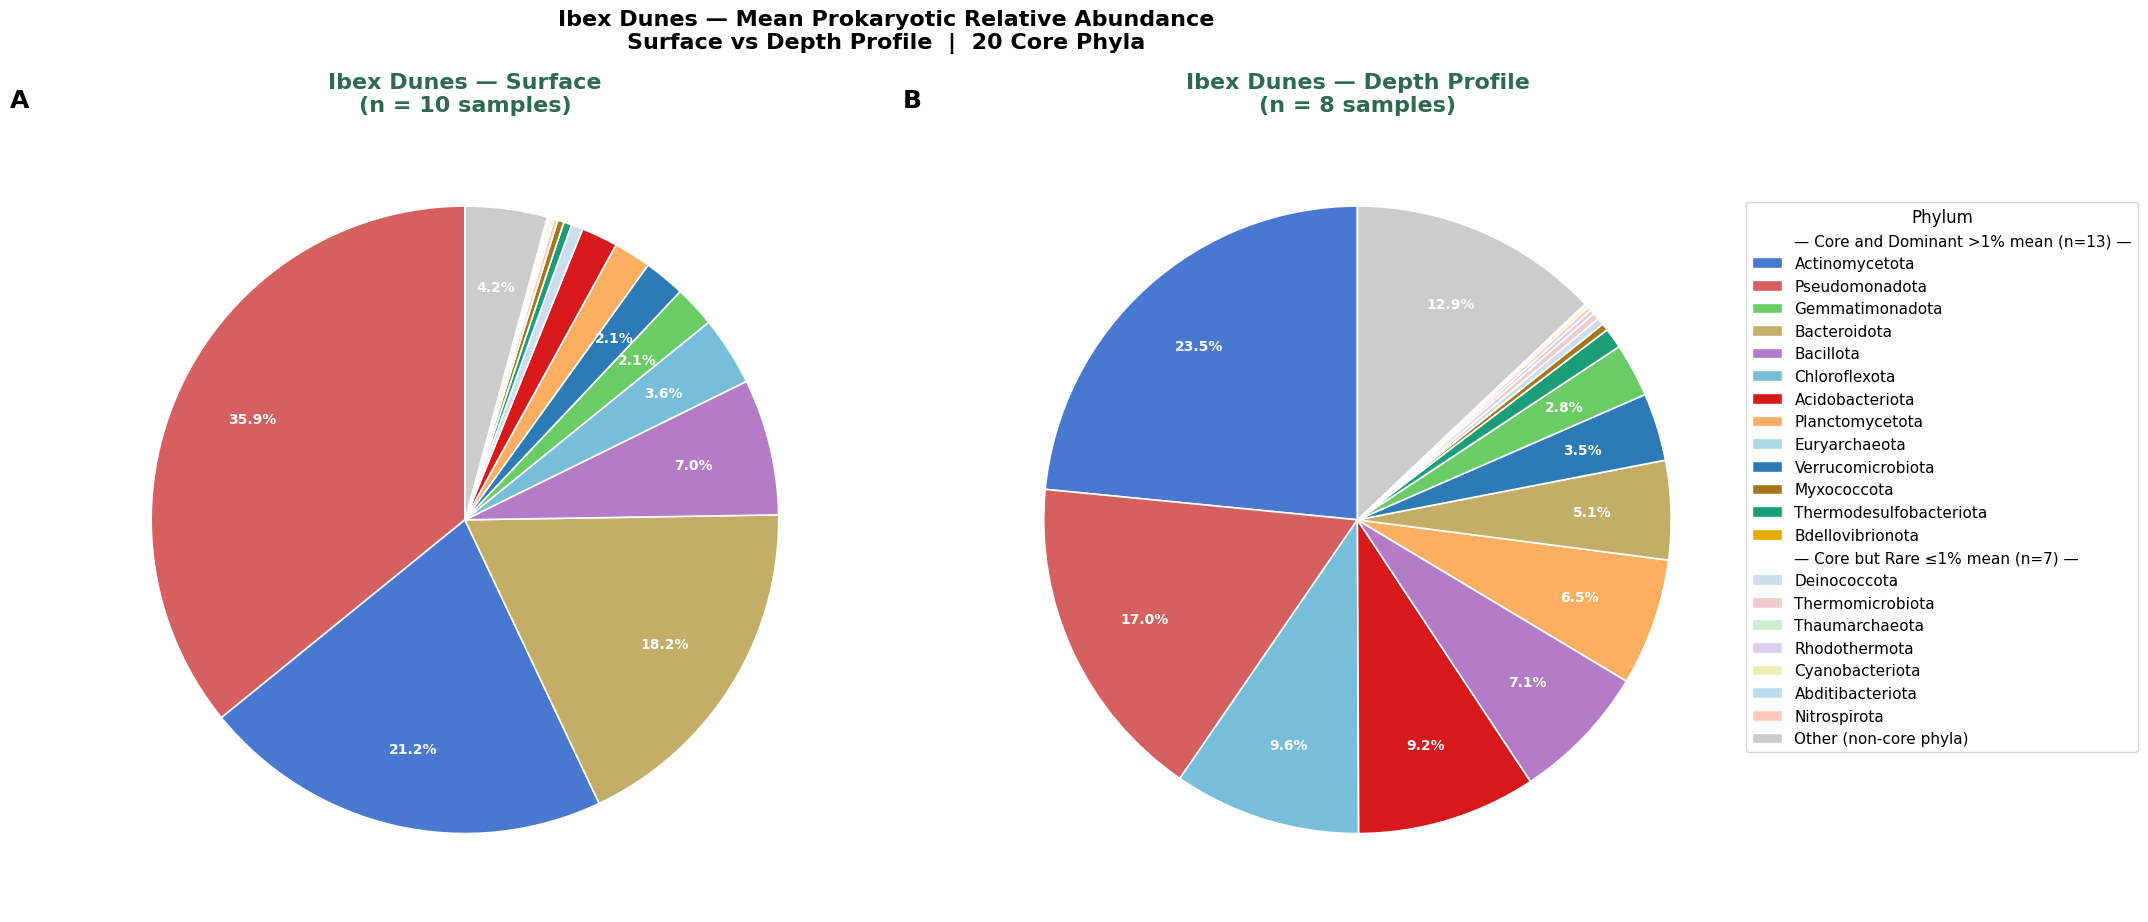

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# LOAD RELATIVE ABUNDANCE FILES
# ============================
rel_surf_path  = "/content/zotutab_decontam_RelAbund_Final.csv"
rel_depth_path = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"

def load_relabund(path):
    raw = pd.read_csv(path, header=None)
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row = 1
        data_start = 2
    else:
        header_row = 0
        data_start = 1
    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)
    return df

df_surf  = load_relabund(rel_surf_path)
df_depth = load_relabund(rel_depth_path)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]

def get_sample_cols(df):
    zotu_col = df.columns[0]
    return [c for c in df.columns
            if c not in tax_cols
            and c != zotu_col
            and "Blank" not in str(c)]

surf_all_cols  = get_sample_cols(df_surf)
depth_all_cols = get_sample_cols(df_depth)

# ============================
# IBEX SAMPLES
# surface = all IX samples in surface file
# depth   = all IX samples in depth file
# ============================
ibex_surf_cols  = [s for s in surf_all_cols
                   if str(s).startswith("IX")]
ibex_depth_cols = [s for s in depth_all_cols
                   if str(s).startswith("IX")]

print(f"Ibex surface samples ({len(ibex_surf_cols)}): "
      f"{ibex_surf_cols}")
print(f"Ibex depth samples  ({len(ibex_depth_cols)}): "
      f"{ibex_depth_cols}")

# ============================
# FILTER PROKARYOTES
# ============================
def filter_prokaryotes(df, sample_cols):
    df = df.copy()
    df["Domain"] = df["Domain"].str.lower().str.strip()
    df["Phylum"] = df["Phylum"].str.lower().str.strip()
    micro = df[
        df["Domain"].isin(["bacteria", "archaea"]) &
        (df["Phylum"] != "bacteria") &
        df["Phylum"].notna()
    ].copy()
    micro[sample_cols] = micro[sample_cols].apply(
        pd.to_numeric, errors="coerce").fillna(0)
    return micro

micro_surf  = filter_prokaryotes(df_surf,  surf_all_cols)
micro_depth = filter_prokaryotes(df_depth, depth_all_cols)

# ============================
# AGGREGATE TO PHYLUM MEANS
# ============================
def get_phylum_means(micro, sample_cols):
    grouped = micro.groupby("Phylum")[sample_cols].sum()
    means   = grouped[sample_cols].mean(axis=1)
    return means.sort_values(ascending=False)

surf_means  = get_phylum_means(micro_surf,  ibex_surf_cols)
depth_means = get_phylum_means(micro_depth, ibex_depth_cols)

# ============================
# CORE PHYLA LIST
# same 20 phyla as top figure
# ============================
core_phyla_list = [
    "actinomycetota", "pseudomonadota", "gemmatimonadota",
    "bacteroidota", "bacillota", "chloroflexota",
    "acidobacteriota", "planctomycetota", "euryarchaeota",
    "verrucomicrobiota", "myxococcota", "thermodesulfobacteriota",
    "bdellovibrionota", "deinococcota", "thermomicrobiota",
    "thaumarchaeota", "rhodothermota", "cyanobacteriota",
    "abditibacteriota", "nitrospirota"
]

# ============================
# PREPARE PIE DATA
# core phyla shown individually
# everything else collapsed into Other
# ============================
def prep_pie_core(means, core_phyla):
    core_vals = {p: float(means[p])
                 for p in core_phyla
                 if p in means.index}
    other_sum = sum(float(v)
                    for p, v in means.items()
                    if p not in core_phyla)

    core_sorted = dict(sorted(core_vals.items(),
                               key=lambda x: x[1],
                               reverse=True))
    labels = list(core_sorted.keys()) + ["Other"]
    values = list(core_sorted.values()) + [other_sum]
    return labels, values

surf_labels,  surf_vals  = prep_pie_core(
    surf_means,  core_phyla_list)
depth_labels, depth_vals = prep_pie_core(
    depth_means, core_phyla_list)

print(f"\nSurface slices: {len(surf_labels)}")
print(f"Depth slices:   {len(depth_labels)}")

# ============================
# COLOR MAP
# match top figure colors exactly
# same phylum = same color in both pies
# ============================
top_fig_colors = {
    "actinomycetota":          "#4878CF",
    "pseudomonadota":          "#D65F5F",
    "gemmatimonadota":         "#6ACC65",
    "bacillota":               "#B47CC7",
    "bacteroidota":            "#C4AD66",
    "chloroflexota":           "#77BEDB",
    "acidobacteriota":         "#D7191C",
    "planctomycetota":         "#FDAE61",
    "euryarchaeota":           "#ABD9E9",
    "verrucomicrobiota":       "#2C7BB6",
    "myxococcota":             "#A6761D",
    "bdellovibrionota":        "#E6AB02",
    "thermodesulfobacteriota": "#1B9E77",
    "deinococcota":            "#CCDDEE",
    "thermomicrobiota":        "#F0CCCC",
    "thaumarchaeota":          "#CCEECC",
    "rhodothermota":           "#DDCCEE",
    "cyanobacteriota":         "#EEEEBB",
    "abditibacteriota":        "#BBDDEE",
    "nitrospirota":            "#FFCCBB",
    "Other":                   "#CCCCCC",
}

# ============================
# FIGURE — two pie charts
# ============================
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor("white")

def draw_pie(ax, labels, values, title,
             n_samples, panel_label):

    colors = [top_fig_colors.get(l, "#CCCCCC")
              for l in labels]

    def autopct_fmt(pct):
        return f"{pct:.1f}%" if pct >= 2.0 else ""

    wedges, texts, autotexts = ax.pie(
        values,
        colors=colors,
        autopct=autopct_fmt,
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(edgecolor="white",
                        linewidth=1.2),
    )
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    ax.set_title(
        f"{title}\n(n = {n_samples} samples)",
        fontsize=16, fontweight="bold",
        color="#2d6a4f", pad=12)

    ax.text(-0.08, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

draw_pie(axes[0],
         surf_labels, surf_vals,
         "Ibex Dunes — Surface",
         len(ibex_surf_cols), "A")

draw_pie(axes[1],
         depth_labels, depth_vals,
         "Ibex Dunes — Depth Profile",
         len(ibex_depth_cols), "B")

# ============================
# LEGEND
# dominant core phyla first then rare core then other
# ============================
dominant_core = [
    "actinomycetota", "pseudomonadota", "gemmatimonadota",
    "bacteroidota", "bacillota", "chloroflexota",
    "acidobacteriota", "planctomycetota", "euryarchaeota",
    "verrucomicrobiota", "myxococcota", "thermodesulfobacteriota",
    "bdellovibrionota"
]
rare_core = [
    "deinococcota", "thermomicrobiota", "thaumarchaeota",
    "rhodothermota", "cyanobacteriota", "abditibacteriota",
    "nitrospirota"
]

legend_handles = []

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label="— Core and Dominant >1% mean (n=13) —"))
for p in dominant_core:
    legend_handles.append(
        Patch(facecolor=top_fig_colors[p],
              edgecolor="white",
              label=p.capitalize()))

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label="— Core but Rare ≤1% mean (n=7) —"))
for p in rare_core:
    legend_handles.append(
        Patch(facecolor=top_fig_colors[p],
              edgecolor="white",
              label=p.capitalize()))

legend_handles.append(
    Patch(facecolor="#CCCCCC", edgecolor="white",
          label="Other (non-core phyla)"))

fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.20, 0.5),
    fontsize=11, frameon=True,
    edgecolor="#cccccc",
    title="Phylum",
    title_fontsize=12,
)

fig.suptitle(
    "Ibex Dunes — Mean Prokaryotic Relative Abundance\n"
    "Surface vs Depth Profile  |  20 Core Phyla",
    fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()

plt.show()


Depth samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']
Depth OTU matrix: (8, 6014)

Mantel test — BC vs depth difference:
  r = 0.838  p = 0.0010  **


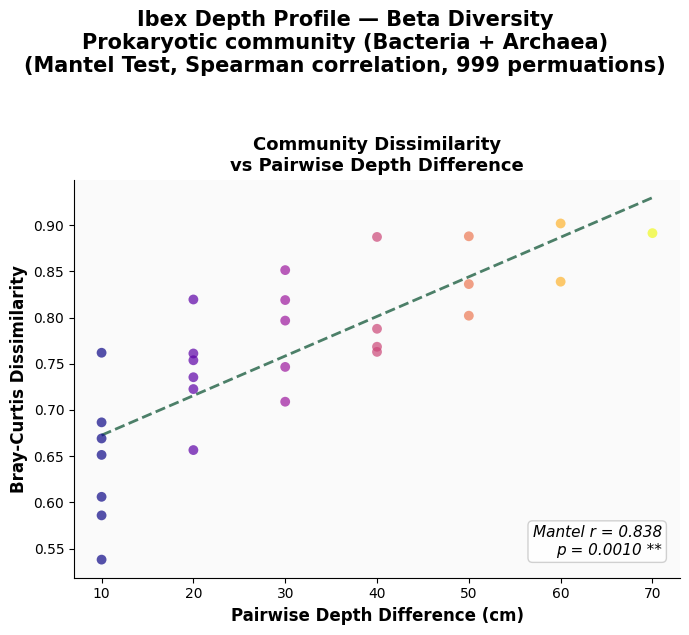

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, linregress
from skbio.stats.distance import mantel, DistanceMatrix

# ============================
# PATHS
# ============================
depth_rel_path = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"

# ============================
# DEPTH MAP
# ============================
depth_map = {
    "IX.10CM.A":  10,
    "IX.20CM.B":  20,
    "IX.30CM.A":  30,
    "IX.40CM.A":  40,
    "IX.50CM.A":  50,
    "IX.60CM.A":  60,
    "IX.70CM.A":  70,
    "IX.80CM.A":  80,
}

# ============================
# TAXONOMY COLUMNS
# ============================
tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]

# ============================
# IBEX COLOR
# ============================
color = "#2d6a4f"

# ============================
# LOAD RELABUND DEPTH FILE
# ============================
raw_r     = pd.read_csv(depth_rel_path, header=None)
first_val = str(raw_r.iloc[0, 0]).strip().upper()

if first_val == "ANATOMY":
    header_row_r = 1
    data_start_r = 2
else:
    header_row_r = 0
    data_start_r = 1

df_r = raw_r.iloc[data_start_r:].copy()
df_r.columns = raw_r.iloc[header_row_r].values
df_r.reset_index(drop=True, inplace=True)

zotu_col_r    = df_r.columns[0]
sample_cols_r = [c for c in df_r.columns
                 if c not in tax_cols
                 and c != zotu_col_r
                 and "Blank" not in str(c)]

df_r[sample_cols_r] = df_r[sample_cols_r].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_r["Domain"] = df_r["Domain"].str.lower().str.strip()
df_r["Phylum"] = df_r["Phylum"].str.lower().str.strip()

micro_r = df_r[
    df_r["Domain"].isin(["bacteria", "archaea"]) &
    (df_r["Phylum"] != "bacteria") &
    df_r["Phylum"].notna()
].copy()

# ============================
# DEPTH SAMPLES — sorted by depth
# ============================
depth_samps_r = [s for s in sample_cols_r
                 if s in depth_map]
depth_samps_r.sort(key=lambda s: depth_map[s])

print(f"Depth samples: {depth_samps_r}")

# ============================
# BUILD OTU MATRIX
# ============================
otu_depth = (
    micro_r.set_index(zotu_col_r)[depth_samps_r]
    .T.fillna(0)
)
otu_depth.index.name   = None
otu_depth.columns.name = None

print(f"Depth OTU matrix: {otu_depth.shape}")

# ============================
# BRAY-CURTIS DISTANCE MATRIX
# ============================
bc_mat = squareform(pdist(
    otu_depth.values.astype(float),
    metric="braycurtis"))

n          = len(depth_samps_r)
idx        = np.triu_indices(n, k=1)
depths_arr = np.array([depth_map[s]
                        for s in depth_samps_r])
depth_diff = np.abs(
    depths_arr[:, None] - depths_arr[None, :])

x_pairs = depth_diff[idx]
y_pairs = bc_mat[idx]

# ============================
# MANTEL TEST
# pairwise BC vs pairwise depth difference
# ============================
ids = list(range(n))
r_m, p_m, _ = mantel(
    DistanceMatrix(depth_diff, ids=ids),
    DistanceMatrix(bc_mat,     ids=ids),
    method="spearman", permutations=999)

sig_m = ("***" if p_m < 0.001 else
         "**"  if p_m < 0.01  else
         "*"   if p_m < 0.05  else "ns")

print(f"\nMantel test — BC vs depth difference:")
print(f"  r = {r_m:.3f}  p = {p_m:.4f}  {sig_m}")

# ============================
# FIGURE — single panel
# Community Dissimilarity vs Pairwise Depth Difference
# ============================
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("white")

ax.scatter(x_pairs, y_pairs,
           c=x_pairs, cmap="plasma",
           alpha=0.7, s=50, linewidths=0,
           vmin=x_pairs.min(), vmax=x_pairs.max(),
           zorder=3)

slope, intercept, _, _, _ = linregress(x_pairs, y_pairs)
x_ln = np.linspace(x_pairs.min(), x_pairs.max(), 200)
ax.plot(x_ln, slope * x_ln + intercept,
        color=color, linewidth=2,
        linestyle="--", alpha=0.85)

ax.text(0.97, 0.05,
        f"Mantel r = {r_m:.3f}\n"
        f"p = {p_m:.4f} {sig_m}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

ax.set_xlabel("Pairwise Depth Difference (cm)",
              fontsize=12, fontweight="bold")
ax.set_ylabel("Bray-Curtis Dissimilarity",
              fontsize=12, fontweight="bold")
ax.set_title(
    "Community Dissimilarity\nvs Pairwise Depth Difference",
    fontsize=13, fontweight="bold")
ax.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax.spines[sp_].set_visible(False)

fig.suptitle(
    "Ibex Depth Profile — Beta Diversity\n"
    "Prokaryotic community (Bacteria + Archaea)\n(Mantel Test, Spearman correlation, 999 permuations)",
    fontsize=15, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 10.8 MB/s eta 0:00:00


Prokaryotic ZOTUs: 6014  |  Samples: 52
Surface samples: 52
Depth samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']
Depth OTU matrix: (8, 6014)
Combined matrix: (60, 6014)

PCoA variance: PCo1=15.6%  PCo2=11.3%

PERMANOVA surface vs depth:
  p = 0.0010  **
PERMANOVA surface vs depth:
  R² = 14.7%
  p  = 0.0010  **


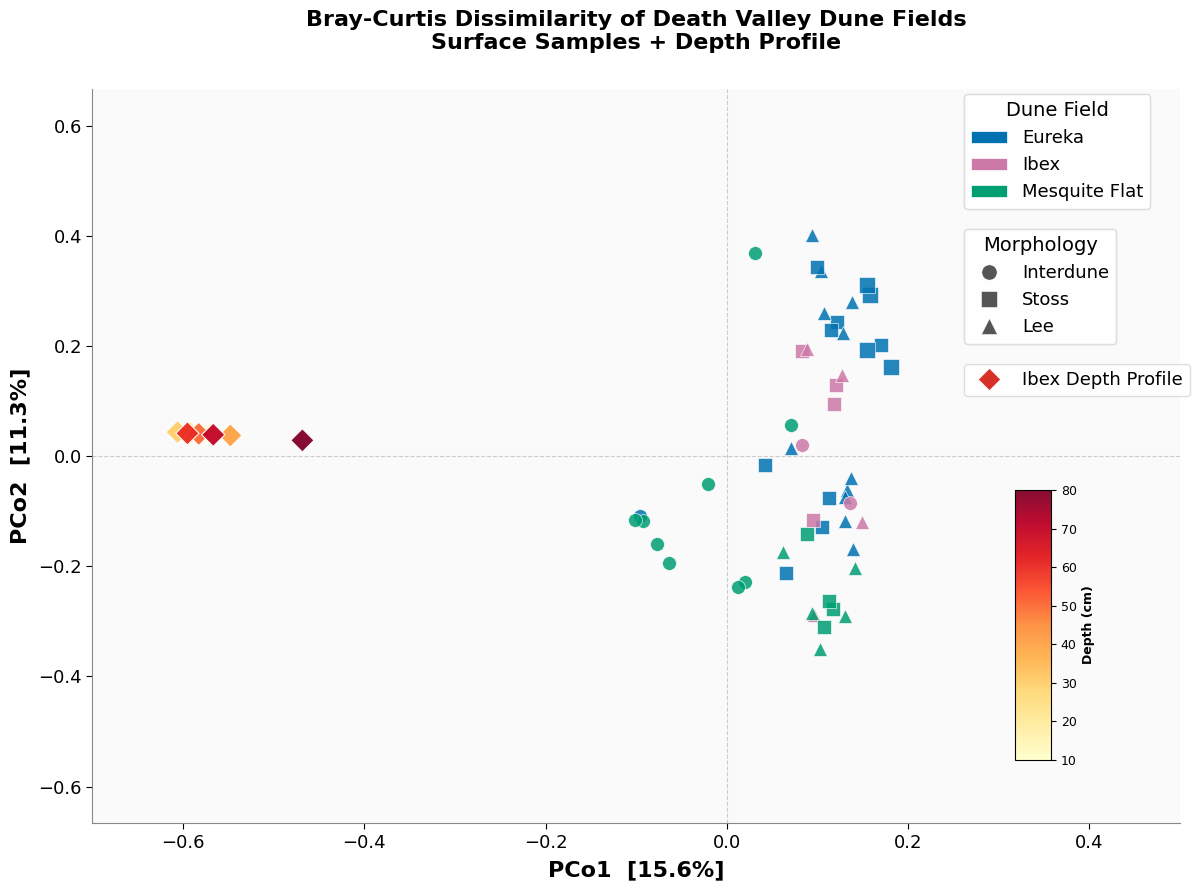

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ============================
# LOAD SURFACE OTU
# ============================
def load_otu(path):
    raw = pd.read_csv(path, header=None)
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row = 1
        data_start = 2
    else:
        header_row = 0
        data_start = 1

    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)

    n_tax     = 7
    tax_cols  = list(df.columns[-n_tax:])
    samp_cols = [c for c in df.columns[1:]
                 if c not in tax_cols
                 and c != df.columns[0]
                 and "Blank" not in str(c)]

    for col in samp_cols:
        df[col] = pd.to_numeric(df[col],
                                errors="coerce").fillna(0)

    domain_col = tax_cols[0]
    df[domain_col] = (df[domain_col].astype(str)
                      .str.strip().str.lower())
    micro = df[df[domain_col].isin(
        ["bacteria", "archaea"])].copy()

    print(f"Prokaryotic ZOTUs: {len(micro)}  "
          f"|  Samples: {len(samp_cols)}")

    return pd.DataFrame(
        micro[samp_cols].values.T,
        index=samp_cols,
        columns=micro[micro.columns[0]]
    )

otu_surf = load_otu("/content/zotutab_decontam_Final.csv")

meta = pd.read_csv("/content/PERM_metadata.csv").rename(
           columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

shared   = sorted(set(otu_surf.index) & set(meta.index))
otu_surf = otu_surf.loc[shared]
meta_aln = meta.loc[shared].copy()
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

print(f"Surface samples: {len(shared)}")

# ============================
# LOAD DEPTH OTU
# uses relabund depth file
# ============================
rel_depth_path = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"
raw_dep = pd.read_csv(rel_depth_path, header=None)

first_val_d = str(raw_dep.iloc[0, 0]).strip().upper()
if first_val_d == "ANATOMY":
    header_row_d = 1
    data_start_d = 2
else:
    header_row_d = 0
    data_start_d = 1

df_dep = raw_dep.iloc[data_start_d:].copy()
df_dep.columns = raw_dep.iloc[header_row_d].values
df_dep.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col_d = df_dep.columns[0]

sample_cols_d = [c for c in df_dep.columns
                 if c not in tax_cols
                 and c != zotu_col_d
                 and "Blank" not in str(c)]

df_dep[sample_cols_d] = df_dep[sample_cols_d].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_dep["Domain"] = df_dep["Domain"].str.lower().str.strip()
df_dep["Phylum"] = df_dep["Phylum"].str.lower().str.strip()

micro_dep = df_dep[
    df_dep["Domain"].isin(["bacteria", "archaea"]) &
    (df_dep["Phylum"] != "bacteria") &
    df_dep["Phylum"].notna()
].copy()

depth_map = {
    "IX.10CM.A": 10, "IX.20CM.B": 20,
    "IX.30CM.A": 30, "IX.40CM.A": 40,
    "IX.50CM.A": 50, "IX.60CM.A": 60,
    "IX.70CM.A": 70, "IX.80CM.A": 80,
}

depth_samps = [s for s in sample_cols_d if s in depth_map]
depth_samps.sort(key=lambda s: depth_map[s])

otu_depth = (
    micro_dep.set_index(zotu_col_d)[depth_samps]
    .T.fillna(0)
)
otu_depth.index.name   = None
otu_depth.columns.name = None

print(f"Depth samples: {depth_samps}")
print(f"Depth OTU matrix: {otu_depth.shape}")

# ============================
# COMBINE SURFACE + DEPTH
# align columns (ZOTUs)
# ============================
all_cols      = otu_surf.columns.union(otu_depth.columns)
otu_surf_aln  = otu_surf.reindex(
    columns=all_cols, fill_value=0)
otu_depth_aln = otu_depth.reindex(
    columns=all_cols, fill_value=0)

otu_combined = pd.concat([otu_surf_aln, otu_depth_aln])
print(f"Combined matrix: {otu_combined.shape}")

# ============================
# BRAY-CURTIS ON COMBINED
# ============================
bc_comb = squareform(pdist(
    otu_combined.values.astype(float),
    metric="braycurtis"))

# ============================
# PCoA
# ============================
D2   = bc_comb ** 2
B    = -0.5 * (D2
               - D2.mean(1, keepdims=True)
               - D2.mean(0, keepdims=True)
               + D2.mean())
ev, evec = np.linalg.eigh(B)
idx  = np.argsort(ev)[::-1]
ev   = ev[idx]
evec = evec[:, idx]
pos  = ev > 0
coords_comb = evec[:, pos] * np.sqrt(ev[pos])
var_comb    = ev[pos] / ev[pos].sum() * 100

print(f"\nPCoA variance: PCo1={var_comb[0]:.1f}%  "
      f"PCo2={var_comb[1]:.1f}%")

# ============================
# PERMANOVA — surface vs depth
# ============================
n_surf  = len(shared)
n_depth = len(depth_samps)

group_labels = ["surface"] * n_surf + ["depth"] * n_depth
group_series = pd.Series(
    group_labels,
    index=list(otu_combined.index),
    name="Group")

dm_comb  = DistanceMatrix(bc_comb,
                           ids=list(otu_combined.index))
res_perm = permanova(dm_comb, group_series,
                     permutations=999)
p_perm   = res_perm["p-value"]
sig_perm = ("***" if p_perm < 0.001 else
            "**"  if p_perm < 0.01  else
            "*"   if p_perm < 0.05  else "ns")

print(f"\nPERMANOVA surface vs depth:")
print(f"  p = {p_perm:.4f}  {sig_perm}")

# ============================
# HELPER FUNCTIONS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite Flat"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX") and "CM" not in str(s):
        return "Ibex"
    return "Other"

FIELD_COLORS = {
    "Eureka":        "#0072B2",  # blue
    "Ibex":          "#CC79A7",  # reddish purple / pink
    "Mesquite Flat": "#009E73",  # bluish green
}

MORPH_STYLE = {
    "Interdune":        ("o", 100),
    "Stoss":            ("s",  95),
    "Lee":              ("^", 100),
    "Stoss, Depth":     ("s",  95),
    "Stoss , Depth":    ("s",  95),
    "Interdune, Depth": ("o",  95),
    "Stoss, Star":      ("s", 140),
    "Stoss , Star":     ("s", 140),
    "Lee, Star":        ("^", 100),
    "Stoss, Crest":     ("s",  95),
}
# ============================
# PERMANOVA R² — surface vs depth
# Anderson (2001) formula
# consistent with all other PERMANOVA
# ============================
groups   = np.array(group_labels)
n        = len(groups)
unique   = np.unique(groups)

ss_total = np.sum(bc_comb ** 2) / n
ss_within = sum(
    np.sum(bc_comb[np.ix_(
        np.where(groups == g)[0],
        np.where(groups == g)[0])] ** 2) /
    len(np.where(groups == g)[0])
    for g in unique
    if len(np.where(groups == g)[0]) > 1
)
r2_depth = (ss_total - ss_within) / ss_total

print(f"PERMANOVA surface vs depth:")
print(f"  R² = {r2_depth*100:.1f}%")
print(f"  p  = {p_perm:.4f}  {sig_perm}")
# ============================
# FIGURE
# ============================
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("white")

# ============================
# PLOT SURFACE SAMPLES
# coloured by field, shaped by morphology
# ============================
fields = [get_field(s) for s in shared]
morphs = meta_aln["Morphology"].fillna(
    "Interdune").str.strip().tolist()

for i in range(n_surf):
    fc     = FIELD_COLORS.get(fields[i], "gray")
    mk, sz = MORPH_STYLE.get(morphs[i], ("o", 100))
    ax.scatter(coords_comb[i, 0], coords_comb[i, 1],
               color=fc, marker=mk, s=sz,
               edgecolors="white", linewidths=0.5,
               alpha=0.85, zorder=3)

# ============================
# PLOT DEPTH SAMPLES
# coloured by depth using colormap
# diamond marker
# ============================
depth_vals_plot = [depth_map[s] for s in depth_samps]

sc = ax.scatter(
    coords_comb[n_surf:, 0],
    coords_comb[n_surf:, 1],
    c=depth_vals_plot,
    cmap="YlOrRd",
    marker="D", s=140,
    edgecolors="white", linewidths=0.8,
    alpha=0.95, zorder=5,
    vmin=10, vmax=80)

# # label depth points
# for i, (x_c, y_c, d) in enumerate(zip(
#         coords_comb[n_surf:, 0],
#         coords_comb[n_surf:, 1],
#         depth_vals_plot)):
#     if d in [10, 40, 80]: # Only label 10cm, 40cm, and 80cm
#         ax.annotate(f"{d}cm", (x_c, y_c),
#                     textcoords="offset points",
#                     xytext=(8, 4), fontsize=12,
#                     color="#333333")

# colorbar for depth
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.3])

cbar = fig.colorbar(sc, cax=cbar_ax, shrink=0.3,
                     pad=0.03, aspect=15)
cbar.set_label("Depth (cm)", fontsize=9,
               fontweight="bold")
cbar.ax.tick_params(labelsize=9)





# ============================
# AXES
# ============================
h = max(abs(coords_comb[:, 0]).max(),
        abs(coords_comb[:, 1]).max()) * 1.10

ax.axhline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.axvline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.set_xlim(-.7, .5)
ax.set_ylim(-h, h)
#BRO

ax.set_xlabel(f"PCo1  [{var_comb[0]:.1f}%]",
              fontsize=16, fontweight="bold", labelpad=6)
ax.set_ylabel(f"PCo2  [{var_comb[1]:.1f}%]",
              fontsize=16, fontweight="bold", labelpad=6)




ax.set_title(
    "Bray-Curtis Dissimilarity of Death Valley Dune Fields\n"
    "Surface Samples + Depth Profile\n ",
    fontsize=16, fontweight="bold", pad=12)
ax.tick_params(labelsize=13, length=4, width=0.8)
ax.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax.spines[sp_].set_visible(False)
for sp_ in ["bottom", "left"]:
    ax.spines[sp_].set_color("#888888")

# ============================
# PERMANOVA annotation
# ============================
# ax.text(0.02, 0.05,
#         f"PERMANOVA surface vs depth\n"
#         f"p = {p_perm:.4f} {sig_perm}",
#         transform=ax.transAxes,
#         ha="left", va="bottom",
#         fontsize=11, style="italic",
#         bbox=dict(boxstyle="round,pad=0.3",
#                   facecolor="white",
#                   edgecolor="#cccccc",
#                   alpha=0.9))

# ============================
# LEGENDS
# field colours + morphology symbols
# + depth profile indicator
# ============================
field_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white",
                   lw=0.5, label=f)
    for f, c in FIELD_COLORS.items()
]

morph_legend_items = [
    ("Interdune", "o", 11),
    ("Stoss",     "s", 11),
    ("Lee",       "^", 11),
]
morph_handles = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#555555",
               markeredgecolor="white",
               markeredgewidth=0.4,
               markersize=ms, label=mo, linewidth=0)
    for mo, mk, ms in morph_legend_items
]

depth_handle = plt.Line2D(
    [0],[0], marker="D", color="w",
    markerfacecolor="#D73027",
    markeredgecolor="white",
    markeredgewidth=0.4,
    markersize=11,
    label="Ibex Depth Profile",
    linewidth=0)

leg1 = fig.legend(
    handles=field_handles,
    title="Dune Field",
    loc="upper left",
    bbox_to_anchor=(.8, 0.9),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

leg2 = fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="upper left",
    bbox_to_anchor=(.8, 0.75),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

leg3 = fig.legend(
    handles=[depth_handle],
    #title="Depth profile",
    loc="upper left",
    bbox_to_anchor=(.8, 0.6),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

fig.add_artist(leg1)
fig.add_artist(leg2)

plt.tight_layout()


Building PCoA of surface + depth samples...
Combined matrix: (18, 6014)

PERMANOVA surface vs depth:
  p = 0.0010  **


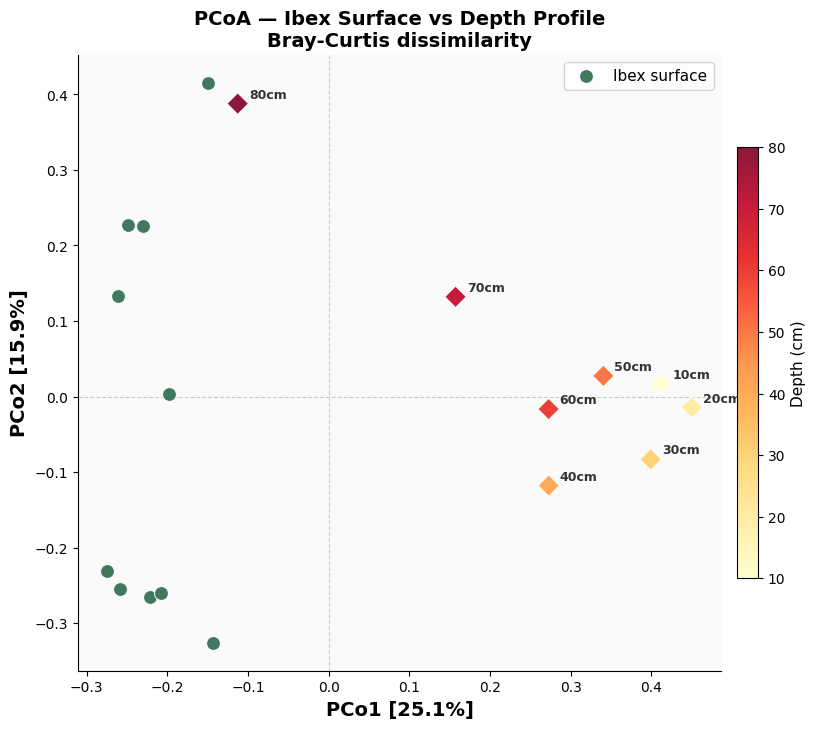

In [8]:
# ============================
# FIGURE 3 — PCoA
# surface + depth together
# coloured by depth
# ============================
print("\nBuilding PCoA of surface + depth samples...")

# load surface relabund
rel_surf_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw_s = pd.read_csv(rel_surf_path, header=None)
df_s  = raw_s.iloc[2:].copy()
df_s.columns = raw_s.iloc[1]
df_s.reset_index(drop=True, inplace=True)

surf_sample_cols = [c for c in df_s.columns
                    if c not in tax_cols
                    and c != df_s.columns[0]
                    and "Blank" not in str(c)]

df_s[surf_sample_cols] = df_s[surf_sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_s["Domain"] = df_s["Domain"].str.lower().str.strip()
df_s["Phylum"] = df_s["Phylum"].str.lower().str.strip()

micro_s = df_s[
    df_s["Domain"].isin(["bacteria", "archaea"]) &
    (df_s["Phylum"] != "bacteria") &
    df_s["Phylum"].notna()
].copy()

# Ibex surface samples only
ibex_surf = [s for s in surf_sample_cols
             if s.startswith("IX")
             and "CM" not in s]

zotu_col_s = micro_s.columns[0]
otu_surf_ibex = (
    micro_s.set_index(zotu_col_s)[ibex_surf]
    .T.fillna(0)
)

# align columns between surface and depth
all_cols = otu_surf_ibex.columns.union(
    otu_depth.columns)
otu_surf_aln  = otu_surf_ibex.reindex(
    columns=all_cols, fill_value=0)
otu_depth_aln = otu_depth.reindex(
    columns=all_cols, fill_value=0)

otu_combined = pd.concat(
    [otu_surf_aln, otu_depth_aln])

print(f"Combined matrix: {otu_combined.shape}")

# PCoA
bc_comb = squareform(pdist(
    otu_combined.values.astype(float),
    metric="braycurtis"))

D2   = bc_comb ** 2
B    = -0.5 * (D2
               - D2.mean(1, keepdims=True)
               - D2.mean(0, keepdims=True)
               + D2.mean())
ev, evec = np.linalg.eigh(B)
idx  = np.argsort(ev)[::-1]
ev   = ev[idx]; evec = evec[:, idx]
pos  = ev > 0
coords = evec[:, pos] * np.sqrt(ev[pos])
var    = ev[pos] / ev[pos].sum() * 100

fig3, ax3 = plt.subplots(figsize=(10, 8))
fig3.patch.set_facecolor("white")

n_surf  = len(ibex_surf)
n_depth = len(depth_samps_r)

# surface Ibex samples
ax3.scatter(coords[:n_surf, 0], coords[:n_surf, 1],
            c="#2d6a4f", marker="o", s=100,
            edgecolors="white", linewidths=0.8,
            alpha=0.9, zorder=3,
            label="Ibex surface")

# depth samples coloured by depth
depth_vals_plot = [depth_map[s] for s in depth_samps_r]
sc = ax3.scatter(
    coords[n_surf:, 0], coords[n_surf:, 1],
    c=depth_vals_plot, cmap="YlOrRd",
    marker="D", s=120,
    edgecolors="white", linewidths=0.8,
    alpha=0.9, zorder=4,
    vmin=10, vmax=80)

# label depth points
for i, (x_c, y_c, d) in enumerate(zip(
        coords[n_surf:, 0],
        coords[n_surf:, 1],
        depth_vals_plot)):
    ax3.annotate(f"{d}cm", (x_c, y_c),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=9,
                 color="#333333", fontweight="bold")

cbar = fig3.colorbar(sc, ax=ax3, shrink=0.7,
                     pad=0.02)
cbar.set_label("Depth (cm)", fontsize=11)

ax3.axhline(0, color="#cccccc", lw=0.8,
            ls="--", zorder=1)
ax3.axvline(0, color="#cccccc", lw=0.8,
            ls="--", zorder=1)

ax3.set_xlabel(f"PCo1 [{var[0]:.1f}%]",
               fontsize=14, fontweight="bold")
ax3.set_ylabel(f"PCo2 [{var[1]:.1f}%]",
               fontsize=14, fontweight="bold")
ax3.set_title(
    "PCoA — Ibex Surface vs Depth Profile\n"
    "Bray-Curtis dissimilarity",
    fontsize=14, fontweight="bold")
ax3.legend(fontsize=11, frameon=True,
           edgecolor="#cccccc")
ax3.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax3.spines[sp_].set_visible(False)

# PERMANOVA surface vs depth
group_labels = (["surface"] * n_surf +
                ["depth"]   * n_depth)
group_series = pd.Series(
    group_labels,
    index=list(otu_combined.index),
    name="Group")

dm_comb = DistanceMatrix(bc_comb,
                          ids=list(otu_combined.index))
res_perm = permanova(dm_comb, group_series,
                     permutations=999)
p_perm   = res_perm["p-value"]
sig_perm = ("***" if p_perm < 0.001 else
            "**"  if p_perm < 0.01  else
            "*"   if p_perm < 0.05  else "ns")

print(f"\nPERMANOVA surface vs depth:")
print(f"  p = {p_perm:.4f}  {sig_perm}")



plt.show()

In [9]:

import pandas as pd
import numpy as np
import re
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from statsmodels.stats.multitest import multipletests

INPUT_FILE = "/content/zotutab_decontam_Final_Depth_Only.csv"

# ---------------------------------------------------------------------
# STEP 1: Load and fix the messy 2-row header
# ---------------------------------------------------------------------
raw = pd.read_csv(INPUT_FILE)

new_colnames = raw.iloc[0].tolist()
new_colnames[0] = "ZOTU_ID"  # was "ANATOMY" -> "Zotu" in row 0

df = raw.iloc[1:].copy()
df.columns = new_colnames
df = df.reset_index(drop=True)

print("Fixed columns:", df.columns.tolist())

# ---------------------------------------------------------------------
# STEP 2: Identify sample columns programmatically, EXCLUDE any "MF" samples
# ---------------------------------------------------------------------
taxonomy_col = "Domain"
phylum_col = "Phylum"
non_sample_cols = ["ZOTU_ID", taxonomy_col, phylum_col, "Class", "Order", "Family", "Genus", "Species"]

candidate_sample_cols = [c for c in df.columns if c not in non_sample_cols]
excluded_mf = [c for c in candidate_sample_cols if str(c).upper().startswith("MF")]
sample_cols = [c for c in candidate_sample_cols if not str(c).upper().startswith("MF")]

print(f"\nAll candidate sample columns: {candidate_sample_cols}")
print(f"Excluded (starts with 'MF'): {excluded_mf}")
print(f"Retained for analysis: {sample_cols}")

# Extract depth in cm from sample names like "IX.10CM.A" -> 10
def extract_depth(sample_name):
    match = re.search(r"(\d+)\s*CM", str(sample_name).upper())
    if match:
        return int(match.group(1))
    return None

depth_map = {c: extract_depth(c) for c in sample_cols}
print(f"\nParsed depths: {depth_map}")

unparsed = [c for c, d in depth_map.items() if d is None]
if unparsed:
    raise SystemExit(f"Couldn't parse depth from these sample names: {unparsed}. "
                      f"Fix extract_depth() or set depth_map manually.")

depths = pd.Series(depth_map)[sample_cols]

# Convert sample columns to numeric (came in as object dtype after header fix)
for c in sample_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

df[taxonomy_col] = df[taxonomy_col].astype(str).str.strip()

# ---------------------------------------------------------------------
# STEP 3: Identify Archaea/Bacteria and compute per-sample relative abundance
# ---------------------------------------------------------------------
is_archaea = df[taxonomy_col].str.contains("archaea", case=False, na=False)
is_bacteria = df[taxonomy_col].str.contains("bacteria", case=False, na=False)
print(f"\nArchaeal ZOTUs: {is_archaea.sum()} | Bacterial ZOTUs: {is_bacteria.sum()} (of {len(df)} total)")

sample_totals = df[sample_cols].sum(axis=0)
archaea_reads = df.loc[is_archaea, sample_cols].sum(axis=0)
bacteria_reads = df.loc[is_bacteria, sample_cols].sum(axis=0)
archaea_pct = (archaea_reads / sample_totals) * 100
archaea_bacteria_ratio = archaea_reads / bacteria_reads

print("\nArchaeal relative abundance (%) by sample (in depth order):")
ordered_samples = depths.sort_values().index.tolist()
print(archaea_pct[ordered_samples].to_string())

# ---------------------------------------------------------------------
# TEST 1: Spearman correlation -- archaea % vs depth
# ---------------------------------------------------------------------
rho1, p1 = stats.spearmanr(depths[sample_cols], archaea_pct[sample_cols])
print(f"\n=== TEST 1: Spearman -- Archaea % vs depth ===")
print(f"rho = {rho1:.3f}, p = {p1:.4f}  {'** SIGNIFICANT **' if p1 < 0.05 else '(not significant)'}")

# ---------------------------------------------------------------------
# TEST 2: Linear regression -- effect size for reporting alongside p-value
# ---------------------------------------------------------------------
slope, intercept, r_value, p2, std_err = stats.linregress(depths[sample_cols], archaea_pct[sample_cols])
print(f"\n=== TEST 2: Linear regression -- Archaea % vs depth ===")
print(f"slope = {slope:.4f} %/cm, R^2 = {r_value**2:.3f}, p = {p2:.4f}")

# ---------------------------------------------------------------------
# TEST 3: Archaea:Bacteria ratio vs depth
# ---------------------------------------------------------------------
rho3, p3 = stats.spearmanr(depths[sample_cols], archaea_bacteria_ratio[sample_cols])
print(f"\n=== TEST 3: Spearman -- Archaea:Bacteria ratio vs depth ===")
print(f"rho = {rho3:.3f}, p = {p3:.4f}  {'** SIGNIFICANT **' if p3 < 0.05 else '(not significant)'}")

# ---------------------------------------------------------------------
# TEST 4: Archaeal-only alpha diversity vs depth
# ---------------------------------------------------------------------
archaea_counts = df.loc[is_archaea, sample_cols]
archaea_richness = (archaea_counts > 0).sum(axis=0)

def shannon(counts):
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0
    p = counts / counts.sum()
    return -np.sum(p * np.log(p))

archaea_shannon = archaea_counts.apply(shannon, axis=0)

rho4r, p4r = stats.spearmanr(depths[sample_cols], archaea_richness[sample_cols])
rho4s, p4s = stats.spearmanr(depths[sample_cols], archaea_shannon[sample_cols])
print(f"\n=== TEST 4: Archaeal-only alpha diversity vs depth ===")
print(f"Richness: rho = {rho4r:.3f}, p = {p4r:.4f}  {'** SIGNIFICANT **' if p4r < 0.05 else '(not significant)'}")
print(f"Shannon:  rho = {rho4s:.3f}, p = {p4s:.4f}  {'** SIGNIFICANT **' if p4s < 0.05 else '(not significant)'}")

# ---------------------------------------------------------------------
# TEST 5: Archaeal-only beta diversity vs depth (Mantel-style test)
# ---------------------------------------------------------------------
archaea_relabund_matrix = archaea_counts.div(archaea_counts.sum(axis=0), axis=1).T.fillna(0)
bray_curtis_dist = squareform(pdist(archaea_relabund_matrix.loc[sample_cols].values, metric="braycurtis"))
depth_dist = squareform(pdist(depths[sample_cols].values.reshape(-1, 1), metric="euclidean"))

def mantel_test(dist1, dist2, n_perm=999, seed=42):
    rng = np.random.default_rng(seed)
    iu = np.triu_indices_from(dist1, k=1)
    d1, d2 = dist1[iu], dist2[iu]
    observed_r, _ = stats.spearmanr(d1, d2)
    perm_rs = np.zeros(n_perm)
    n = dist1.shape[0]
    for i in range(n_perm):
        perm_idx = rng.permutation(n)
        d2_perm = dist2[np.ix_(perm_idx, perm_idx)][iu]
        perm_rs[i], _ = stats.spearmanr(d1, d2_perm)
    p_value = (np.sum(np.abs(perm_rs) >= np.abs(observed_r)) + 1) / (n_perm + 1)
    return observed_r, p_value

mantel_r, mantel_p = mantel_test(bray_curtis_dist, depth_dist)
print(f"\n=== TEST 5: Mantel test -- Archaeal COMPOSITION (Bray-Curtis) vs depth ===")
print(f"Mantel r = {mantel_r:.3f}, p = {mantel_p:.4f}  {'** SIGNIFICANT **' if mantel_p < 0.05 else '(not significant)'}")

# ---------------------------------------------------------------------
# TEST 6: Per-phylum breakdown within Archaea (Spearman + FDR)
# ---------------------------------------------------------------------
print(f"\n=== TEST 6: Per-phylum trends within Archaea (Spearman + FDR correction) ===")
archaea_phyla = df.loc[is_archaea, phylum_col].dropna().unique()
results = []
for phylum in archaea_phyla:
    rows = df.loc[is_archaea & (df[phylum_col] == phylum), sample_cols].sum(axis=0)
    pct = (rows / sample_totals) * 100
    if pct.sum() == 0:
        continue
    rho, p = stats.spearmanr(depths[sample_cols], pct[sample_cols])
    results.append({"phylum": phylum, "rho": rho, "p": p, "mean_pct": pct.mean()})

if results:
    taxa_df = pd.DataFrame(results).sort_values("p")
    taxa_df["p_fdr"] = multipletests(taxa_df["p"], method="fdr_bh")[1]
    print(taxa_df.to_string(index=False))
else:
    print("No archaeal phyla found -- check Phylum column values.")

# ---------------------------------------------------------------------
# TEST 7: Shallow vs deep half -- Mann-Whitney U
# ---------------------------------------------------------------------
median_depth = depths[sample_cols].median()
shallow = archaea_pct[sample_cols][depths[sample_cols] <= median_depth]
deep = archaea_pct[sample_cols][depths[sample_cols] > median_depth]
u_stat, p7 = stats.mannwhitneyu(shallow, deep, alternative="two-sided")
print(f"\n=== TEST 7: Mann-Whitney U -- shallow (<= {median_depth}cm, n={len(shallow)}) vs deep (n={len(deep)}) ===")
print(f"Shallow mean: {shallow.mean():.2f}%  |  Deep mean: {deep.mean():.2f}%")
print(f"U = {u_stat:.2f}, p = {p7:.4f}  {'** SIGNIFICANT **' if p7 < 0.05 else '(not significant)'}")

print("\n" + "="*70)
print("SUMMARY -- report rho/R^2 alongside p-values regardless of significance,")
print("given the small sample size (n=8) limits statistical power throughout.")
print("="*70)

Fixed columns: ['ZOTU_ID', 'IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A', 'Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

All candidate sample columns: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']
Excluded (starts with 'MF'): []
Retained for analysis: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Parsed depths: {'IX.10CM.A': 10, 'IX.20CM.B': 20, 'IX.30CM.A': 30, 'IX.40CM.A': 40, 'IX.50CM.A': 50, 'IX.60CM.A': 60, 'IX.70CM.A': 70, 'IX.80CM.A': 80}

Archaeal ZOTUs: 359 | Bacterial ZOTUs: 5655 (of 6014 total)

Archaeal relative abundance (%) by sample (in depth order):
IX.10CM.A    20.471021
IX.20CM.B    18.457202
IX.30CM.A    12.780404
IX.40CM.A     5.828645
IX.50CM.A    16.295599
IX.60CM.A     7.898578
IX.70CM.A     9.437398
IX.80CM.A     3.542157

=== TEST 1: Spearman -- Archaea % vs depth ==

Depth samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']
Surface sample IX.1B richness: 1477
Richness vs depth: rho=0.238  p=0.5702  ns
Combined matrix: (18, 6014)
PERMANOVA surface vs depth: p=0.0010  **


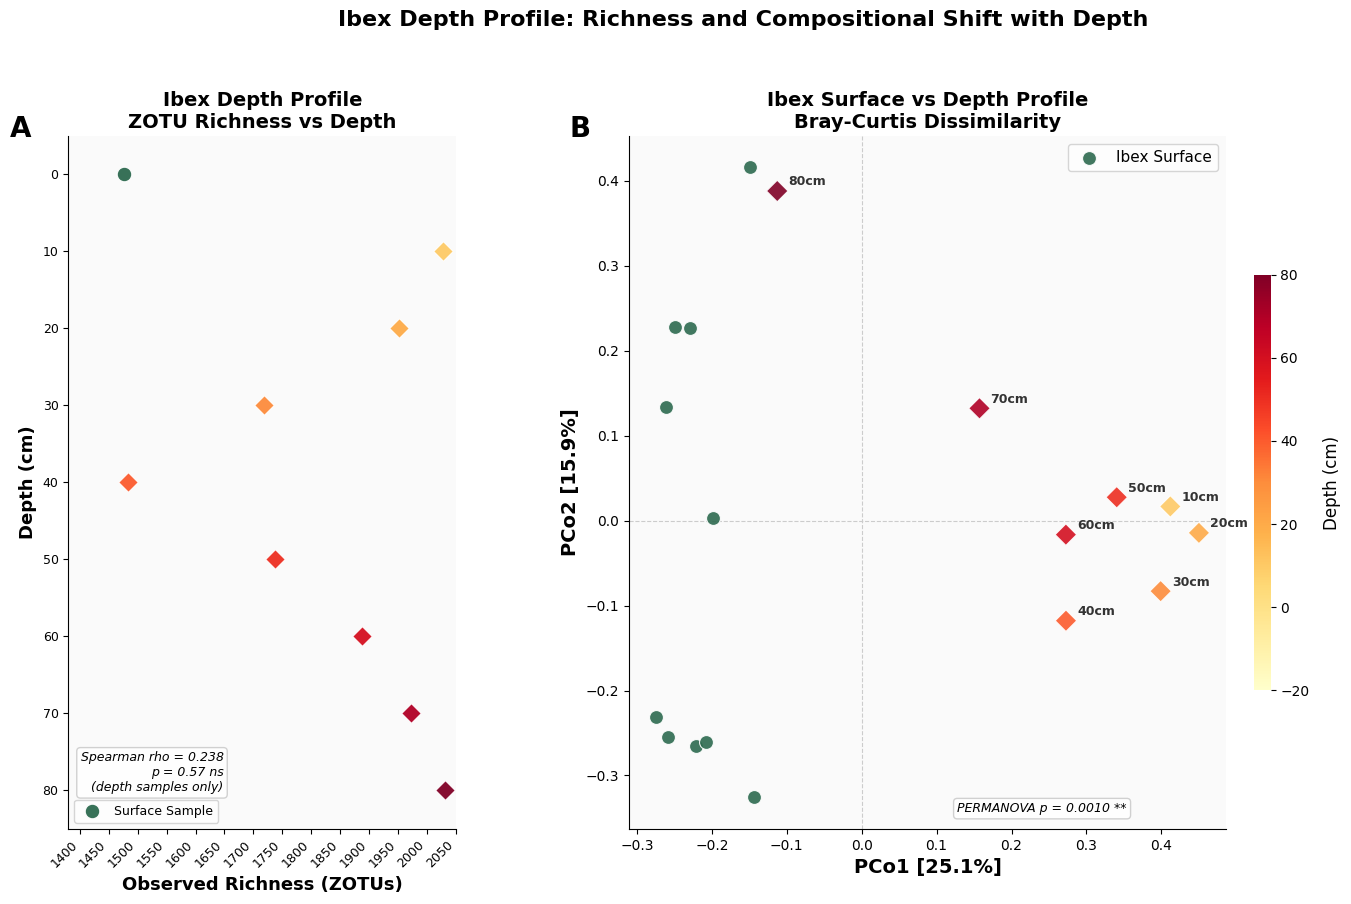

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova

# ============================
# PATHS
# ============================
depth_count_path   = "/content/zotutab_decontam_Final_Depth_Only.csv"
surface_count_path = "/content/zotutab_decontam_Final.csv"
rel_surf_path      = "/content/zotutab_decontam_RelAbund_Final.csv"
rel_depth_path     = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]

depth_map = {
    "IX.10CM.A":  10,
    "IX.20CM.B":  20,
    "IX.30CM.A":  30,
    "IX.40CM.A":  40,
    "IX.50CM.A":  50,
    "IX.60CM.A":  60,
    "IX.70CM.A":  70,
    "IX.80CM.A":  80,
}
surface_sample = "IX.1B"

# shared colormap for depth
DEPTH_CMAP = "YlOrRd"
DEPTH_VMIN =-20
DEPTH_VMAX = 80
SURFACE_COLOR = "#2d6a4f"

# ============================
# GENERIC LOADER
# ============================
def load_taxa_table(path):
    raw = pd.read_csv(path, header=None)
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row, data_start = 1, 2
    else:
        header_row, data_start = 0, 1

    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)

    zotu_col    = df.columns[0]
    sample_cols = [c for c in df.columns
                   if c not in tax_cols
                   and c != zotu_col
                   and "Blank" not in str(c)]

    df[sample_cols] = df[sample_cols].apply(
        pd.to_numeric, errors="coerce").fillna(0)
    df["Domain"] = df["Domain"].str.lower().str.strip()
    df["Phylum"] = df["Phylum"].str.lower().str.strip()

    micro = df[
        df["Domain"].isin(["bacteria", "archaea"]) &
        (df["Phylum"] != "bacteria") &
        df["Phylum"].notna()
    ].copy()

    return micro, zotu_col, sample_cols

# ============================
# PANEL A DATA — RICHNESS VS DEPTH
# ============================
micro_d,        zotu_col_d,   sample_cols_d  = load_taxa_table(depth_count_path)
micro_s_counts, zotu_col_sc,  sample_cols_sc = load_taxa_table(surface_count_path)

depth_samples = [s for s in sample_cols_d if s in depth_map]
depth_samples.sort(key=lambda s: depth_map[s])
print(f"Depth samples: {depth_samples}")

def compute_richness(counts):
    return len(counts[counts > 0])

records = []
for s in depth_samples:
    counts = micro_d[s].values.astype(float)
    rich   = compute_richness(counts)
    records.append({"Sample": s, "Depth_cm": depth_map[s],
                    "Richness": rich, "Type": "depth"})

if surface_sample in micro_s_counts.columns:
    surf_counts = micro_s_counts[surface_sample].values.astype(float)
    surf_rich   = compute_richness(surf_counts)
    records.insert(0, {"Sample": surface_sample, "Depth_cm": 0,
                        "Richness": surf_rich, "Type": "surface"})
    print(f"Surface sample {surface_sample} richness: {surf_rich}")
else:
    print(f"WARNING: {surface_sample} not found")

alpha_depth = pd.DataFrame(records)
depth_only  = alpha_depth[alpha_depth["Type"] == "depth"]
surf_row    = alpha_depth[alpha_depth["Type"] == "surface"]

r_rich, p_rich = spearmanr(depth_only["Depth_cm"],
                            depth_only["Richness"])
sig_rich = ("***" if p_rich < 0.001 else "**" if p_rich < 0.01
            else "*" if p_rich < 0.05 else "ns")
print(f"Richness vs depth: rho={r_rich:.3f}  p={p_rich:.4f}  {sig_rich}")

# ============================
# PANEL B DATA — PCoA SURFACE VS DEPTH
# ============================
micro_surf_pcoa,  zotu_col_sp, surf_sample_cols   = load_taxa_table(rel_surf_path)
micro_depth_pcoa, zotu_col_dp, depth_rel_sample_cols = load_taxa_table(rel_depth_path)

ibex_surf     = [s for s in surf_sample_cols
                 if s.startswith("IX") and "CM" not in s]
depth_samps_r = sorted([s for s in depth_rel_sample_cols
                         if s in depth_map],
                        key=lambda s: depth_map[s])

otu_surf_ibex = (
    micro_surf_pcoa.set_index(zotu_col_sp)[ibex_surf]
    .T.fillna(0)
)
otu_depth = (
    micro_depth_pcoa.set_index(zotu_col_dp)[depth_samps_r]
    .T.fillna(0)
)

all_cols      = otu_surf_ibex.columns.union(otu_depth.columns)
otu_surf_aln  = otu_surf_ibex.reindex(columns=all_cols, fill_value=0)
otu_depth_aln = otu_depth.reindex(columns=all_cols, fill_value=0)
otu_combined  = pd.concat([otu_surf_aln, otu_depth_aln])

print(f"Combined matrix: {otu_combined.shape}")

bc_comb = squareform(pdist(
    otu_combined.values.astype(float), metric="braycurtis"))

D2    = bc_comb ** 2
B_mat = -0.5 * (D2 - D2.mean(1, keepdims=True)
                   - D2.mean(0, keepdims=True) + D2.mean())
ev, evec = np.linalg.eigh(B_mat)
idx      = np.argsort(ev)[::-1]
ev, evec = ev[idx], evec[:, idx]
pos      = ev > 0
coords   = evec[:, pos] * np.sqrt(ev[pos])
var      = ev[pos] / ev[pos].sum() * 100

n_surf         = len(ibex_surf)
depth_vals_plot = [depth_map[s] for s in depth_samps_r]

group_labels = ["surface"] * n_surf + ["depth"] * len(depth_samps_r)
group_series = pd.Series(group_labels,
                          index=list(otu_combined.index),
                          name="Group")
dm_comb  = DistanceMatrix(bc_comb, ids=list(otu_combined.index))
res_perm = permanova(dm_comb, group_series, permutations=999)
p_perm   = res_perm["p-value"]
sig_perm = ("***" if p_perm < 0.001 else "**" if p_perm < 0.01
            else "*" if p_perm < 0.05 else "ns")
print(f"PERMANOVA surface vs depth: p={p_perm:.4f}  {sig_perm}")

# ============================
# COLORMAP HELPER
# maps depth value to colour
# ============================
cmap_obj = plt.get_cmap(DEPTH_CMAP)
norm_obj = Normalize(vmin=DEPTH_VMIN, vmax=DEPTH_VMAX)

def depth_color(d):
    return cmap_obj(norm_obj(d))

# ============================
# FIGURE
# ============================
# change this line
fig = plt.figure(figsize=(18, 9))  # wider overall

# and change this line
gs = GridSpec(1, 2, figure=fig,
              width_ratios=[0.65, 1], wspace=0.35)  # bigger ratio for panel A

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])

# ============================
# PANEL A — RICHNESS VS DEPTH
# depth samples coloured by depth using same colormap
# surface sample green diamond
# ============================

# depth samples — colour from colormap
for _, row in depth_only.iterrows():
    axA.scatter(row["Richness"], row["Depth_cm"],
                color=depth_color(row["Depth_cm"]),
                s=100, edgecolors="white", linewidths=0.8,
                marker="D", alpha=0.95, zorder=3,
                )

# surface sample — green circle
if len(surf_row) > 0:
    axA.scatter(surf_row["Richness"].values[0],
                surf_row["Depth_cm"].values[0],
                color=SURFACE_COLOR, s=110,
                edgecolors="white", linewidths=0.8,
                marker="o", alpha=0.95, zorder=4,
                label=f"Surface Sample") #pot

axA.invert_yaxis()

axA.text(0.4, 0.05, #grit
         f"Spearman rho = {r_rich:.3f}\n"
         f"p = {p_rich:.2f} {sig_rich}\n"
         f"(depth samples only)",
         transform=axA.transAxes,
         ha="right", va="bottom",
         fontsize=9, style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc", alpha=0.9))

axA.text(-0.15, 1.03, "A",
         transform=axA.transAxes,
         fontsize=20, fontweight="bold", va="top")
axA.set_xlabel("Observed Richness (ZOTUs)",
               fontsize=13, fontweight="bold")
axA.set_ylabel("Depth (cm)",
               fontsize=13, fontweight="bold")
axA.set_title("Ibex Depth Profile\nZOTU Richness vs Depth",
              fontsize=14, fontweight="bold")
axA.set_ylim(85, -5)

# ============================
# PANEL A — X AXIS TICKS
# explicit ticks to elongate axis
# ============================
x_min = alpha_depth["Richness"].min()
x_max = alpha_depth["Richness"].max()

# set ticks at every 50 ZOTUs from 1400
tick_start = 1400
tick_end = int(np.ceil(x_max / 50) * 50) + 1   # +1 so arange includes the last multiple of 50
x_ticks  = np.arange(tick_start, tick_end, 50)
axA.set_xticks(x_ticks)
axA.set_xticklabels([str(t) for t in x_ticks], rotation=45, ha="right", fontsize=9)
axA.set_xlim(1380, tick_end + 30)
axA.set_xticks(x_ticks)
axA.set_xticklabels([str(t) for t in x_ticks],
                     rotation=45, ha="right", fontsize=9)
axA.set_xlim(1380, tick_end)

#------
axA.tick_params(labelsize=9)
axA.set_facecolor("#fafafa")
for sp in ["top", "right"]:
    axA.spines[sp].set_visible(False)
axA.legend(fontsize=9, frameon=True,
           edgecolor="#cccccc", loc="lower left")

# ============================
# PANEL B — PCoA SURFACE VS DEPTH
# surface samples green circles
# depth samples diamonds coloured by depth
# ============================
axB.scatter(coords[:n_surf, 0], coords[:n_surf, 1],
            c=SURFACE_COLOR, marker="o", s=100,
            edgecolors="white", linewidths=0.8,
            alpha=0.9, zorder=3, label="Ibex Surface")

sc = axB.scatter(coords[n_surf:, 0], coords[n_surf:, 1],
                  c=depth_vals_plot, cmap=DEPTH_CMAP,
                  marker="D", s=120,
                  edgecolors="white", linewidths=0.8,
                  alpha=0.9, zorder=4,
                  vmin=DEPTH_VMIN, vmax=DEPTH_VMAX)

for x_c, y_c, d in zip(coords[n_surf:, 0],
                         coords[n_surf:, 1],
                         depth_vals_plot):
    axB.annotate(f"{d}cm", (x_c, y_c),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=9,
                 color="#333333", fontweight="bold")

# shared colorbar — applies to both panels
sm  = ScalarMappable(cmap=DEPTH_CMAP,
                     norm=norm_obj)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[axA, axB],
                    shrink=0.6, pad=0.02,
                    location="right", aspect=25)
cbar.set_label("Depth (cm)", fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)

axB.axhline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
axB.axvline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)

axB.text(-0.10, 1.03, "B",
         transform=axB.transAxes,
         fontsize=20, fontweight="bold", va="top")
axB.set_xlabel(f"PCo1 [{var[0]:.1f}%]",
               fontsize=14, fontweight="bold")
axB.set_ylabel(f"PCo2 [{var[1]:.1f}%]",
               fontsize=14, fontweight="bold")
axB.set_title("Ibex Surface vs Depth Profile\n"
              "Bray-Curtis Dissimilarity",
              fontsize=14, fontweight="bold")
axB.text(0.55, 0.02, #grit
         f"PERMANOVA p = {p_perm:.4f} {sig_perm}",
         transform=axB.transAxes,
         ha="left", va="bottom",
         fontsize=9, style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc", alpha=0.9))

axB.legend(fontsize=11, frameon=True,
           edgecolor="#cccccc", loc="upper right")
axB.set_facecolor("#fafafa")
for sp in ["top", "right"]:
    axB.spines[sp].set_visible(False)

fig.suptitle(
    "Ibex Depth Profile: Richness and Compositional Shift with Depth",
    fontsize=16, fontweight="bold", y=1.02)

plt.show()
